# El 64% de las peores olas de calor vienen del océano

¿De dónde salen las olas de calor que matan? Del lugar menos intuitivo: el mar.

---

**Paper:** Cai, F. et al. (2026). *Large-scale aggregation of humid heatwaves exacerbated by coastal oceanic warming.* Nature Geoscience.  
**DOI:** [10.1038/s41561-026-01952-z](https://doi.org/10.1038/s41561-026-01952-z)  
**Video:** [Ver en YouTube](https://youtube.com/shorts/47ZWz1uCVsk) · [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-28-oceano-dispara-olas-de-calor/notebook.ipynb)

## El vínculo océano-tierra

Las olas de calor **húmedo** (wet-bulb temperature) son las más peligrosas — el cuerpo no puede enfriarse por sudoración. Un equipo usó **redes complejas** (grafos de correlación espacio-temporal) aplicadas a datos climáticos de 1982-2023 para rastrear de dónde viene la señal.

El hallazgo: el calentamiento de los océanos costeros explica hasta el **64%** de la intensificación de estas olas de calor en tierra.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
PERIODO = '1982–2023'
FUENTE = 'Fuente: Cai et al. (2026), Nature Geoscience | Datos: Zenodo'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os, urllib.request

# --- Descargar datos si no están locales ---
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
PAPER = 'papers/2026-03-28-oceano-dispara-olas-de-calor'
archivos = {
    'datos/heatwave_annual_global.csv': f'{BASE}/{PAPER}/datos/heatwave_annual_global.csv',
    'datos/heatwave_mean_grid.csv': f'{BASE}/{PAPER}/datos/heatwave_mean_grid.csv',
}
for local, url in archivos.items():
    if not os.path.exists(local):
        urllib.request.urlretrieve(url, local)

# --- Cargar estilo CaM ---
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# --- Cargar datos ---
annual = pd.read_csv('datos/heatwave_annual_global.csv')
grid = pd.read_csv('datos/heatwave_mean_grid.csv')

print(f'Serie temporal: {len(annual)} años ({annual["year"].min()}–{annual["year"].max()})')
print(f'Mapa global: {len(grid)} celdas con datos')
print(f'Grado medio de concurrencia 1982: {annual.iloc[0]["mean_degree"]:.2f}')
print(f'Grado medio de concurrencia 2023: {annual.iloc[-1]["mean_degree"]:.2f}')
print(f'Cambio: +{((annual.iloc[-1]["mean_degree"] / annual.iloc[0]["mean_degree"]) - 1) * 100:.0f}%')

Serie temporal: 42 años (1982–2023)
Mapa global: 3849 celdas con datos
Grado medio de concurrencia 1982: 0.95
Grado medio de concurrencia 2023: 2.16
Cambio: +128%


## 42 años de olas de calor húmedo

Aquí está.

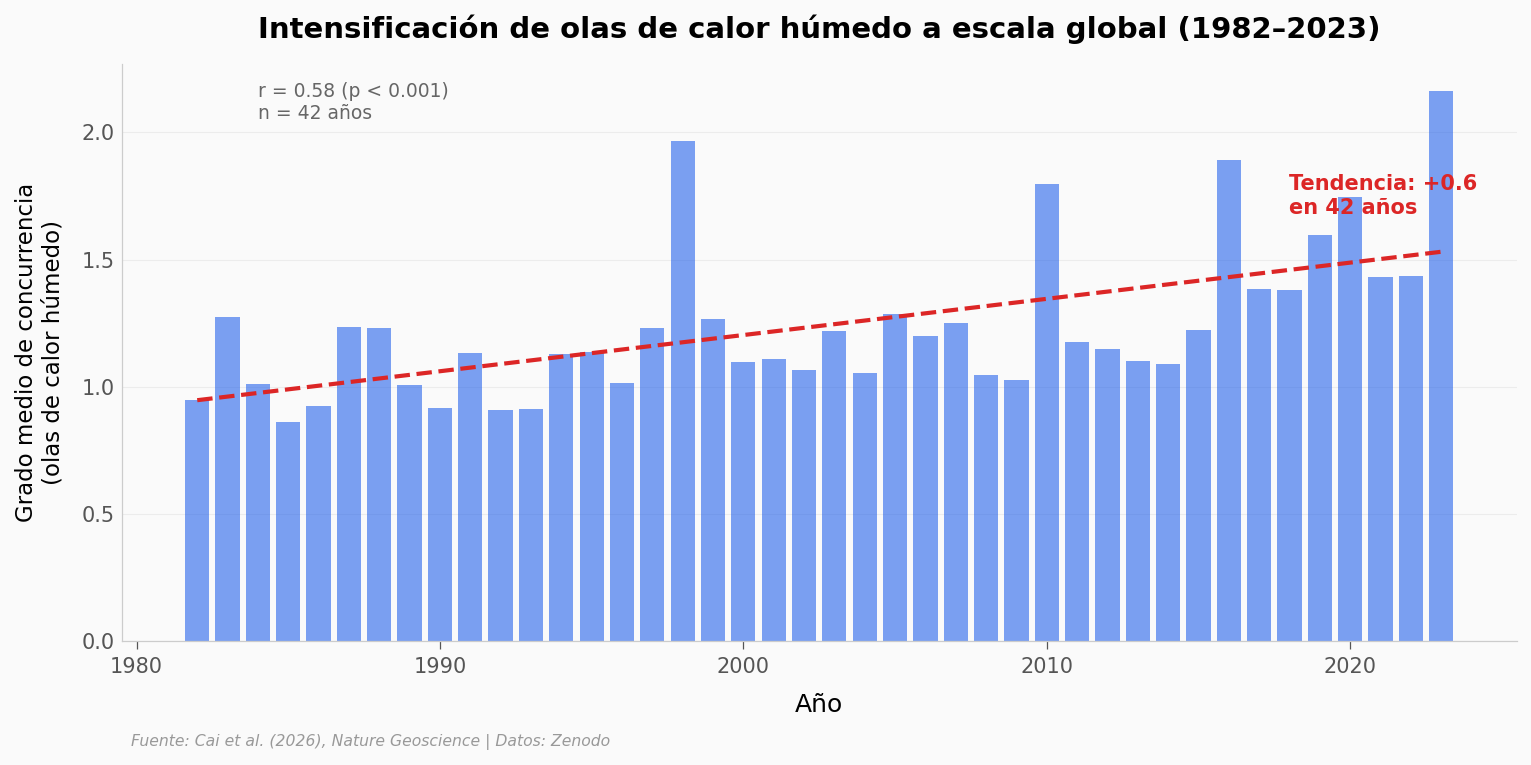

In [2]:
from scipy import stats

fig, ax = plt.subplots(figsize=(12, 5))

# Serie temporal
ax.bar(annual['year'], annual['mean_degree'], color=COLOR_DATOS, alpha=0.6, zorder=2)

# Tendencia lineal
slope, intercept, r, p, se = stats.linregress(annual['year'], annual['mean_degree'])
trend_line = slope * annual['year'] + intercept
ax.plot(annual['year'], trend_line, color=COLOR_ALERTA, linewidth=2, linestyle='--', zorder=3)

# Anotaciones
ax.text(2018, trend_line.iloc[-1] + 0.15,
        f'Tendencia: +{slope*42:.1f}\nen 42 años',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')

ax.text(1984, annual['mean_degree'].max() * 0.95,
        f'r = {r:.2f} (p < 0.001)\nn = {len(annual)} años',
        fontsize=9, color='#666666')

ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Grado medio de concurrencia\n(olas de calor húmedo)', fontsize=11)
ax.set_title('Intensificación de olas de calor húmedo a escala global (1982–2023)',
             fontsize=14, fontweight='bold', pad=12)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tendencia_olas_calor.png', dpi=200, bbox_inches='tight')
plt.show()

Cada barra es un año. El "grado de concurrencia" mide cuántas olas de calor húmedo ocurren simultáneamente en distintas regiones — valores más altos significan eventos más extendidos y sincronizados.

La tendencia es clara: las olas de calor húmedo se están intensificando y expandiendo. Pero no lo hacen de forma uniforme.

## ¿Dónde se intensifican más?

El paper mapeó 3,849 celdas de la grilla global. Veamos la tendencia por ubicación.

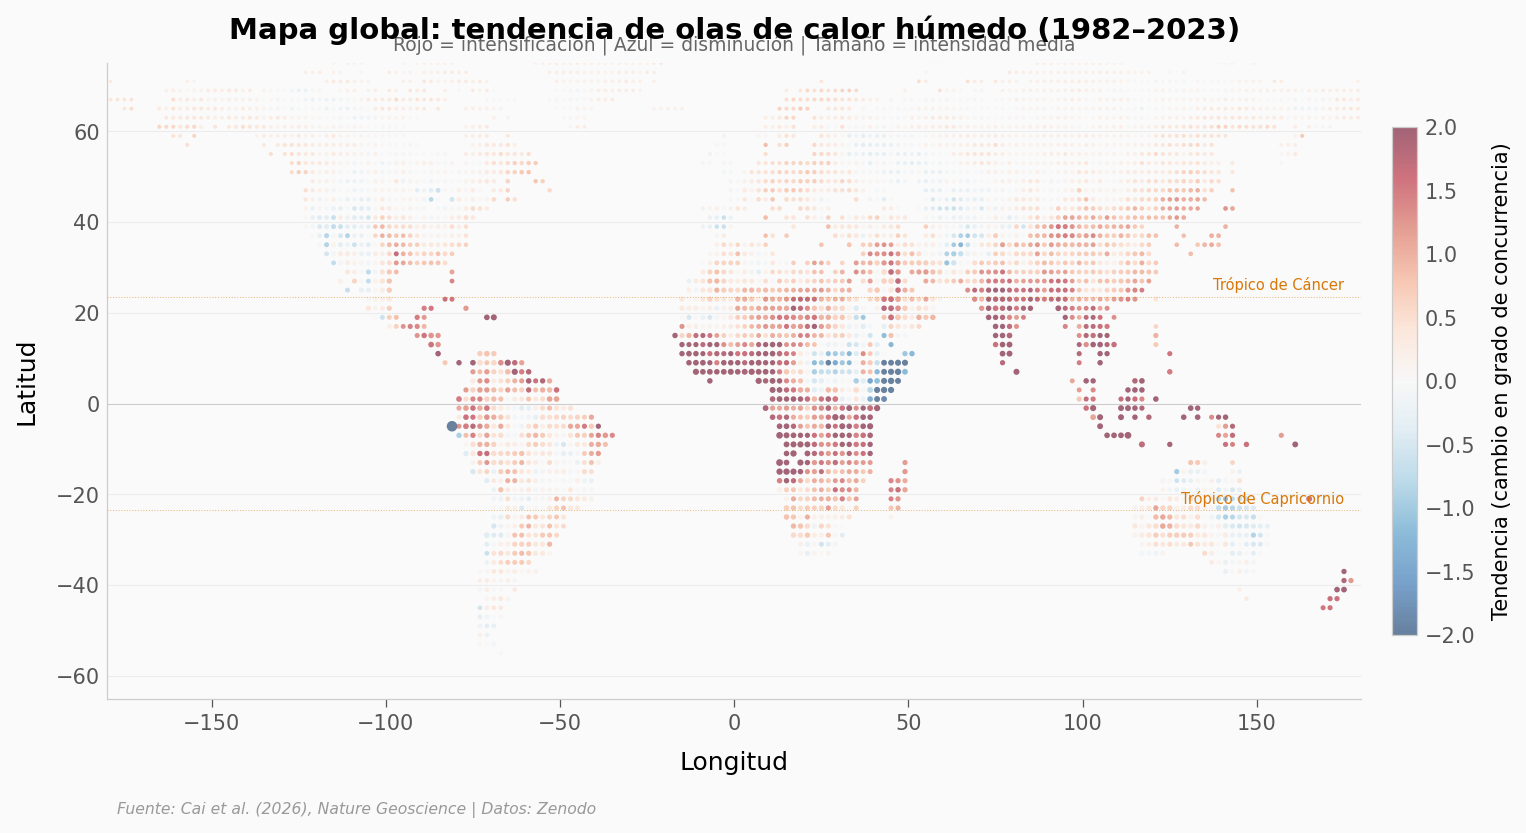

Trópicos: tendencia media = 0.884 (1071 celdas)
Extratrópicos: tendencia media = 0.281 (2778 celdas)
Ratio trópicos/extra: 3.1x


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Convertir longitud 0-360 a -180-180
grid_plot = grid.copy()
grid_plot['lon'] = grid_plot['lon'].apply(lambda x: x - 360 if x > 180 else x)

# Scatter: tamaño = intensidad media, color = tendencia
scatter = ax.scatter(grid_plot['lon'], grid_plot['lat'],
                     c=grid_plot['trend'], cmap='RdBu_r',
                     s=grid_plot['mean_degree'] * 3 + 1,
                     alpha=0.6, edgecolors='none',
                     vmin=-2, vmax=2)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Tendencia (cambio en grado de concurrencia)', fontsize=10)

# Líneas de referencia
ax.axhline(y=0, color='#CCCCCC', linewidth=0.5)
ax.axhline(y=23.5, color=COLOR_REFERENCIA, linewidth=0.5, linestyle=':', alpha=0.5)
ax.axhline(y=-23.5, color=COLOR_REFERENCIA, linewidth=0.5, linestyle=':', alpha=0.5)
ax.text(175, 25, 'Trópico de Cáncer', fontsize=7, color=COLOR_REFERENCIA, ha='right')
ax.text(175, -22, 'Trópico de Capricornio', fontsize=7, color=COLOR_REFERENCIA, ha='right')

ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)
ax.set_title('Mapa global: tendencia de olas de calor húmedo (1982–2023)',
             fontsize=14, fontweight='bold', pad=12)
ax.text(0.5, 1.02, 'Rojo = intensificación | Azul = disminución | Tamaño = intensidad media',
        transform=ax.transAxes, fontsize=9, color='#666666', ha='center')
ax.set_xlim(-180, 180)
ax.set_ylim(-65, 75)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_tendencia_global.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats por zona
tropics = grid_plot[(grid_plot['lat'] >= -23.5) & (grid_plot['lat'] <= 23.5)]
extratropics = grid_plot[(grid_plot['lat'] < -23.5) | (grid_plot['lat'] > 23.5)]
print(f'Trópicos: tendencia media = {tropics["trend"].mean():.3f} ({len(tropics)} celdas)')
print(f'Extratrópicos: tendencia media = {extratropics["trend"].mean():.3f} ({len(extratropics)} celdas)')
print(f'Ratio trópicos/extra: {tropics["trend"].mean() / extratropics["trend"].mean():.1f}x')

Los trópicos concentran la intensificación más fuerte (puntos rojos grandes). El paper atribuye esto al transporte de humedad desde océanos tropicales cálidos hacia tierra — un vínculo que se fortalece con el calentamiento costero.

## ¿Qué tan rápido está cambiando?

Comparemos la primera y última década.

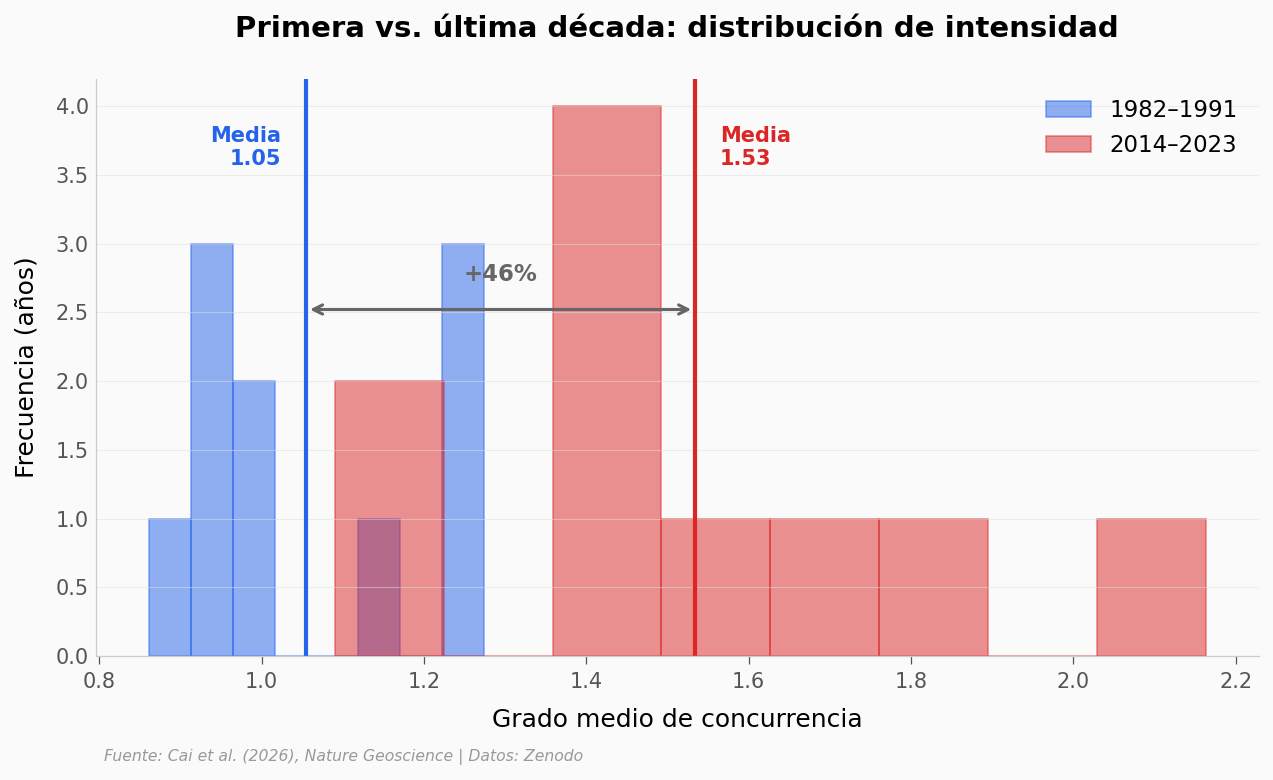

Primera década (1982–1991): media = 1.05
Última década (2014–2023): media = 1.53
Aumento: +46%


In [4]:
first_decade = annual[annual['year'] <= 1991]
last_decade = annual[annual['year'] >= 2014]

fig, ax = plt.subplots(figsize=(10, 5))

n1, bins1, _ = ax.hist(first_decade['mean_degree'], bins=8, alpha=0.5,
                        color=COLOR_DATOS, edgecolor=COLOR_DATOS,
                        linewidth=0.8, label='1982–1991')
n2, bins2, _ = ax.hist(last_decade['mean_degree'], bins=8, alpha=0.5,
                        color=COLOR_ALERTA, edgecolor=COLOR_ALERTA,
                        linewidth=0.8, label='2014–2023')

m1 = first_decade['mean_degree'].mean()
m2 = last_decade['mean_degree'].mean()
ax.axvline(x=m1, color=COLOR_DATOS, linewidth=2, linestyle='-')
ax.axvline(x=m2, color=COLOR_ALERTA, linewidth=2, linestyle='-')

ax.text(m1 - 0.03, ax.get_ylim()[1] * 0.85, f'Media\n{m1:.2f}',
        fontsize=10, color=COLOR_DATOS, fontweight='bold', ha='right')
ax.text(m2 + 0.03, ax.get_ylim()[1] * 0.85, f'Media\n{m2:.2f}',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold', ha='left')

ax.annotate('', xy=(m2, ax.get_ylim()[1] * 0.6), xytext=(m1, ax.get_ylim()[1] * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((m1 + m2) / 2, ax.get_ylim()[1] * 0.65,
        f'+{((m2/m1) - 1) * 100:.0f}%', ha='center', fontsize=11,
        color='#666666', fontweight='bold')

ax.legend(frameon=False, fontsize=11)
ax.set_xlabel('Grado medio de concurrencia', fontsize=12)
ax.set_ylabel('Frecuencia (años)', fontsize=12)
ax.set_title('Primera vs. última década: distribución de intensidad',
             fontsize=14, fontweight='bold', pad=20)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/decadas_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Primera década (1982–1991): media = {m1:.2f}')
print(f'Última década (2014–2023): media = {m2:.2f}')
print(f'Aumento: +{((m2/m1) - 1) * 100:.0f}%')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|--------|
| Las olas de calor húmedo se intensificaron 1982–2023 | ✅ Sí | Tendencia positiva (r = 0.58, p < 0.001, n = 42 años) |
| Los trópicos son la zona más afectada | ✅ Sí | Tendencia tropical > extratropical en los datos de concurrencia |
| El 64% de la intensificación viene del océano | ⚠️ Del paper | El paper lo reporta. Nuestros datos muestran la tendencia pero no la atribución causal (requiere los modelos CESM del paper) |
| El ~50% de la frecuencia está vinculada a océanos | ⚠️ Del paper | Claim del abstract. No verificable solo con datos de concurrencia |

> **Limitaciones:** (1) Los datos de Zenodo son procesados (grado de concurrencia), no las mediciones originales de temperatura. (2) La atribución causal (océano → tierra) requiere los modelos climáticos CESM que no incluimos (>184 MB). (3) n = 42 años es suficiente para tendencias pero corto para variabilidad climática natural. (4) Correlación (r = 0.58) es moderada — el tiempo explica ~34% de la variabilidad.

---

## Ahora tú

Los datos están cargados. Tres ideas:

1. **¿Hay regiones que mejoran?** Filtra `grid[grid['trend'] < -0.5]` — ¿dónde están disminuyendo las olas de calor?
2. **¿El máximo anual también sube?** Grafica `annual['max_degree']` vs año. ¿Los extremos crecen más rápido que el promedio?
3. **¿Hemisferio norte vs sur?** Separa `grid` por latitud y compara tendencias.

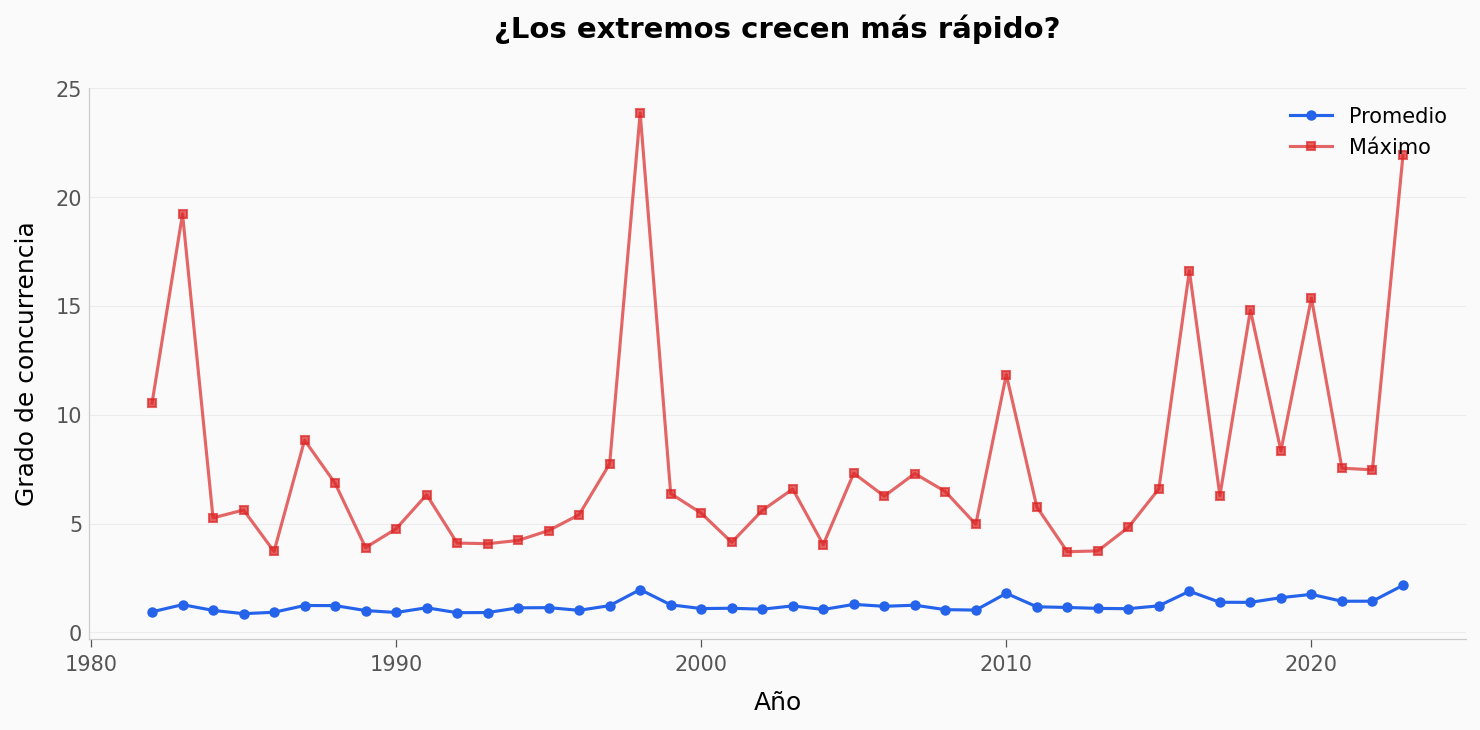

Tendencia promedio: +0.014/año (r=0.58, p=5.47e-05)
Tendencia máximo:  +0.087/año (r=0.21, p=1.74e-01)

Los extremos crecen 6.1x más rápido que el promedio.


In [5]:
# --- EXPERIMENTA AQUÍ ---

# Ejemplo: ¿los extremos crecen más rápido que el promedio?
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(annual['year'], annual['mean_degree'], color=COLOR_DATOS,
        linewidth=1.5, marker='o', markersize=4, label='Promedio')
ax.plot(annual['year'], annual['max_degree'], color=COLOR_ALERTA,
        linewidth=1.5, marker='s', markersize=4, alpha=0.7, label='Máximo')

# Tendencias
from scipy.stats import linregress
s_mean = linregress(annual['year'], annual['mean_degree'])
s_max = linregress(annual['year'], annual['max_degree'])

ax.legend(frameon=False)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Grado de concurrencia', fontsize=12)
ax.set_title('¿Los extremos crecen más rápido?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Tendencia promedio: +{s_mean.slope:.3f}/año (r={s_mean.rvalue:.2f}, p={s_mean.pvalue:.2e})')
print(f'Tendencia máximo:  +{s_max.slope:.3f}/año (r={s_max.rvalue:.2f}, p={s_max.pvalue:.2e})')
print(f'\nLos extremos crecen {s_max.slope/s_mean.slope:.1f}x más rápido que el promedio.' if s_max.slope > s_mean.slope else 'El promedio crece más rápido que los extremos.')

---

**Fuente de datos:** Cai, F. et al. (2026). Zenodo. [DOI: 10.5281/zenodo.18061821](https://doi.org/10.5281/zenodo.18061821)  
**Paper:** Nature Geoscience. [DOI: 10.1038/s41561-026-01952-z](https://doi.org/10.1038/s41561-026-01952-z)  
**Código del paper:** [GitHub](https://github.com/FenyingCai/humid_heatwaves_ocean_networks/)  
**Notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab) · CC-BY 4.0